# Bearing Fault Classification - Feature Engineering Boost

目标：通过**原始波形特征增强** + **不平衡处理** + **GroupCV** 提升宏F1。

方案：
1. 自动识别平台数据路径
2. 从 `signals/*.npy` 提取额外特征（频谱、包络频谱、缺陷频率能量比）
3. 合并原始表格特征 + 新特征
4. 使用 `GroupKFold(case_id)` 做一层三模型（LGB/CAT/XGB）
5. 二层用 LGB 融合（输入包含一层OOF概率 + 全量特征）
6. 输出 `working/submission.csv`


In [1]:
import os
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import hilbert
from scipy.stats import skew, kurtosis

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import lightgbm as lgb
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
N_CLASSES = 4


In [2]:
# 路径自动识别（平台优先，兼容本地）
def find_data_dir() -> Path:
    candidates = [
        Path('./dataset/public'),
        Path('/root/setup/solution/dataset/public'),
        Path('/kaggle/input/public'),
        Path('/kaggle/working/dataset/public'),
        Path('./public'),
        Path('.'),
    ]
    for p in candidates:
        if (p / 'train.csv').exists() and (p / 'test.csv').exists() and (p / 'signals').exists():
            return p.resolve()

    for root in [Path('.'), Path('/root/setup/solution')]:
        if not root.exists():
            continue
        for train_file in root.rglob('train.csv'):
            parent = train_file.parent
            if (parent / 'test.csv').exists() and (parent / 'signals').exists():
                return parent.resolve()

    raise FileNotFoundError('Cannot locate train.csv/test.csv/signals folder')


def find_output_dir() -> Path:
    candidates = [
        Path('./working'),
        Path('/root/setup/solution/working'),
        Path('/kaggle/working'),
        Path('.'),
    ]
    for p in candidates:
        try:
            p.mkdir(parents=True, exist_ok=True)
            probe = p / '.write_test'
            probe.write_text('ok', encoding='utf-8')
            probe.unlink(missing_ok=True)
            return p.resolve()
        except Exception:
            continue
    raise PermissionError('No writable output directory found')


DATA_DIR = find_data_dir()
OUTPUT_DIR = find_output_dir()
TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'
SIGNALS_DIR = DATA_DIR / 'signals'

print('DATA_DIR  :', DATA_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)


DATA_DIR  : /Users/songling/Desktop/public
OUTPUT_DIR: /Users/songling/Desktop/public/working


In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print('train:', train_df.shape)
print('test :', test_df.shape)
print('target distribution:')
print(train_df['Bearing_health_state'].value_counts().sort_index())
print()
print('train cases:', train_df['case_id'].nunique())
print('test cases :', test_df['case_id'].nunique())
print('case overlap:', len(set(train_df['case_id']) & set(test_df['case_id'])))


train: (4878, 41)
test : (1568, 40)
target distribution:
Bearing_health_state
0    4212
1     328
2      23
3     315
Name: count, dtype: int64

train cases: 7
test cases : 4
case overlap: 0


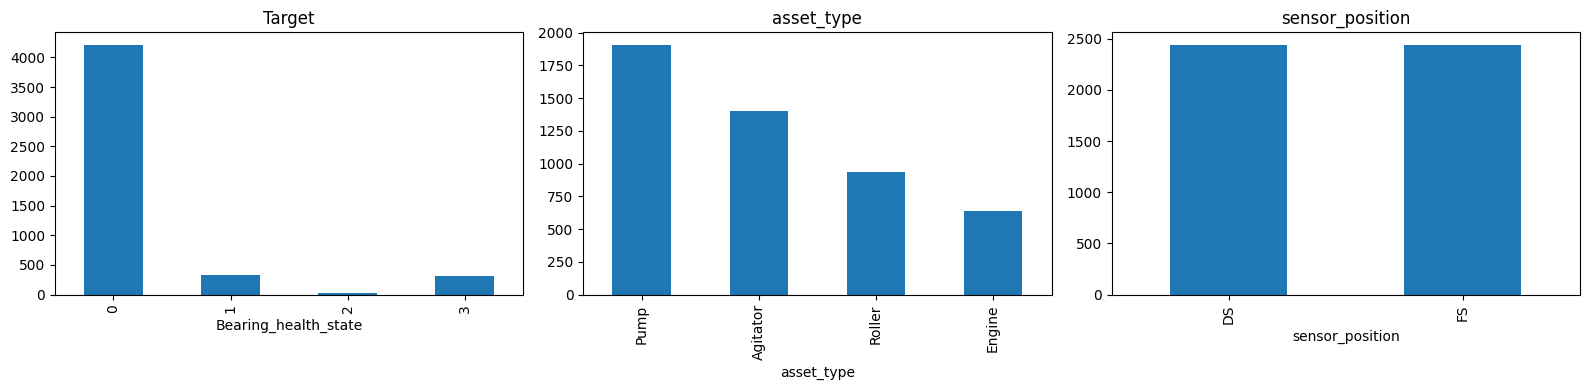

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
train_df['Bearing_health_state'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Target')
train_df['asset_type'].value_counts().plot(kind='bar', ax=axes[1], title='asset_type')
train_df['sensor_position'].value_counts().plot(kind='bar', ax=axes[2], title='sensor_position')
plt.tight_layout()
plt.show()


In [5]:
# 额外特征工程（表格层）
def add_table_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    eps = 1e-9

    out['rot_hz'] = out['rpm'] / 60.0
    out['nyquist_hz'] = out['sampling_rate'] / 2.0

    out['ftf_hz'] = out['ftf_multiple'] * out['rot_hz']
    out['bpf_hz'] = out['bpf_multiple'] * out['rot_hz']
    out['bpfo_hz'] = out['bpfo_multiple'] * out['rot_hz']
    out['bpfi_hz'] = out['bpfi_multiple'] * out['rot_hz']

    out['ftf_norm'] = out['ftf_hz'] / (out['nyquist_hz'] + eps)
    out['bpf_norm'] = out['bpf_hz'] / (out['nyquist_hz'] + eps)
    out['bpfo_norm'] = out['bpfo_hz'] / (out['nyquist_hz'] + eps)
    out['bpfi_norm'] = out['bpfi_hz'] / (out['nyquist_hz'] + eps)

    out['fft_peak_hz'] = out['fft_peak_freq_norm'] * out['nyquist_hz']
    out['peak_order'] = out['fft_peak_hz'] / (out['rot_hz'] + eps)

    out['delta_ftf'] = np.abs(out['fft_peak_hz'] - out['ftf_hz'])
    out['delta_bpf'] = np.abs(out['fft_peak_hz'] - out['bpf_hz'])
    out['delta_bpfo'] = np.abs(out['fft_peak_hz'] - out['bpfo_hz'])
    out['delta_bpfi'] = np.abs(out['fft_peak_hz'] - out['bpfi_hz'])
    out['min_fault_delta'] = out[['delta_ftf', 'delta_bpf', 'delta_bpfo', 'delta_bpfi']].min(axis=1)

    out['band_energy_sum'] = out['band_energy_low'] + out['band_energy_mid_low'] + out['band_energy_mid_high'] + out['band_energy_high']
    out['band_low_ratio'] = out['band_energy_low'] / (np.abs(out['band_energy_sum']) + eps)
    out['band_mid_low_ratio'] = out['band_energy_mid_low'] / (np.abs(out['band_energy_sum']) + eps)
    out['band_mid_high_ratio'] = out['band_energy_mid_high'] / (np.abs(out['band_energy_sum']) + eps)
    out['band_high_ratio'] = out['band_energy_high'] / (np.abs(out['band_energy_sum']) + eps)

    out['rpm_is_zero'] = (out['rpm'] == 0).astype(int)
    out['signal_seconds'] = out['signal_length'] / (out['sampling_rate'] + eps)

    out['peak_rms_ratio2'] = out['peak'] / (out['rms'] + eps)
    out['std_rms_ratio'] = out['std'] / (out['rms'] + eps)

    return out


In [6]:
# 原始波形特征提取（重点提分）
def _safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def _band_energy_ratio(freqs, power, center_hz, total_power, n_harm=5):
    if center_hz <= 0 or not np.isfinite(center_hz):
        return 0.0
    e = 0.0
    nyq = freqs[-1]
    for h in range(1, n_harm + 1):
        f0 = center_hz * h
        if f0 <= 0 or f0 >= nyq:
            continue
        bw = max(1.5, 0.02 * f0)
        mask = (freqs >= f0 - bw) & (freqs <= f0 + bw)
        if mask.any():
            e += power[mask].sum()
    return float(_safe_div(e, total_power))


def extract_signal_features(row, signals_dir: Path):
    mid = int(row['measurement_id'])
    sr = float(row['sampling_rate'])
    rpm = float(row['rpm'])
    rot_hz = rpm / 60.0

    path = signals_dir / f'{mid:05d}.npy'
    x = np.load(path).astype(np.float64)
    n = len(x)

    if n < 16 or sr <= 0:
        return {'measurement_id': mid}

    x0 = x - x.mean()
    abs_x = np.abs(x0)

    rms = np.sqrt(np.mean(x0**2))
    std = np.std(x0)
    peak = np.max(abs_x)

    # FFT power
    spec = np.fft.rfft(x0)
    mag = np.abs(spec)
    power = mag**2 + 1e-12
    freqs = np.fft.rfftfreq(n, d=1.0/sr)

    total_power = power.sum()
    p_norm = power / total_power

    # spectral stats
    spec_entropy = float(-np.sum(p_norm * np.log(p_norm)) / np.log(len(p_norm)))
    centroid_hz = float(np.sum(freqs * power) / total_power)
    bw_hz = float(np.sqrt(np.sum(((freqs - centroid_hz) ** 2) * power) / total_power))
    rolloff_idx = np.searchsorted(np.cumsum(power), 0.85 * total_power)
    rolloff_hz = float(freqs[min(rolloff_idx, len(freqs) - 1)])
    flatness = float(np.exp(np.mean(np.log(power))) / np.mean(power))

    peak_idx = int(np.argmax(power[1:]) + 1) if len(power) > 1 else 0
    fft_peak_hz = float(freqs[peak_idx])
    fft_peak_power_ratio = float(power[peak_idx] / total_power)

    # envelope spectrum
    env = np.abs(hilbert(x0))
    env = env - env.mean()
    env_spec = np.fft.rfft(env)
    env_power = np.abs(env_spec)**2 + 1e-12
    env_total = env_power.sum()

    # defect frequencies
    ftf_hz = float(row['ftf_multiple']) * rot_hz
    bpf_hz = float(row['bpf_multiple']) * rot_hz
    bpfo_hz = float(row['bpfo_multiple']) * rot_hz
    bpfi_hz = float(row['bpfi_multiple']) * rot_hz

    feats = {
        'measurement_id': mid,
        'sig_abs_mean': float(abs_x.mean()),
        'sig_mad': float(np.mean(np.abs(x0 - np.median(x0)))),
        'sig_skew': float(skew(x0)),
        'sig_kurt': float(kurtosis(x0)),
        'sig_crest': float(_safe_div(peak, rms)),
        'sig_impulse': float(_safe_div(peak, abs_x.mean())),
        'sig_shape': float(_safe_div(rms, abs_x.mean())),
        'sig_zero_cross_rate': float(np.mean((x0[:-1] * x0[1:]) < 0)),

        'fft_spec_entropy': spec_entropy,
        'fft_centroid_hz2': centroid_hz,
        'fft_bandwidth_hz2': bw_hz,
        'fft_rolloff85_hz': rolloff_hz,
        'fft_flatness': flatness,
        'fft_peak_hz2': fft_peak_hz,
        'fft_peak_power_ratio': fft_peak_power_ratio,
        'fft_peak_order2': float(_safe_div(fft_peak_hz, rot_hz if rot_hz > 0 else 1e-12)),

        'fft_rot_energy_ratio': _band_energy_ratio(freqs, power, rot_hz, total_power, n_harm=8),
        'fft_ftf_energy_ratio': _band_energy_ratio(freqs, power, ftf_hz, total_power, n_harm=5),
        'fft_bpf_energy_ratio': _band_energy_ratio(freqs, power, bpf_hz, total_power, n_harm=5),
        'fft_bpfo_energy_ratio': _band_energy_ratio(freqs, power, bpfo_hz, total_power, n_harm=5),
        'fft_bpfi_energy_ratio': _band_energy_ratio(freqs, power, bpfi_hz, total_power, n_harm=5),

        'env_rms': float(np.sqrt(np.mean(env**2))),
        'env_kurt': float(kurtosis(env)),
        'env_spec_entropy': float(-np.sum((env_power/env_total) * np.log(env_power/env_total)) / np.log(len(env_power))),
        'env_rot_energy_ratio': _band_energy_ratio(freqs, env_power, rot_hz, env_total, n_harm=8),
        'env_ftf_energy_ratio': _band_energy_ratio(freqs, env_power, ftf_hz, env_total, n_harm=5),
        'env_bpf_energy_ratio': _band_energy_ratio(freqs, env_power, bpf_hz, env_total, n_harm=5),
        'env_bpfo_energy_ratio': _band_energy_ratio(freqs, env_power, bpfo_hz, env_total, n_harm=5),
        'env_bpfi_energy_ratio': _band_energy_ratio(freqs, env_power, bpfi_hz, env_total, n_harm=5),
    }
    return feats


In [7]:
# 提取并缓存 raw 特征
all_df = pd.concat([train_df.drop(columns=['Bearing_health_state']), test_df], axis=0, ignore_index=True)
all_df = add_table_features(all_df)

cache_dir = OUTPUT_DIR / 'cache'
cache_dir.mkdir(parents=True, exist_ok=True)
raw_feat_path = cache_dir / 'raw_signal_features_v2.csv'

if raw_feat_path.exists():
    raw_feat_df = pd.read_csv(raw_feat_path)
    print('Loaded cached raw features:', raw_feat_df.shape)
else:
    feats = []
    for _, r in all_df.iterrows():
        feats.append(extract_signal_features(r, SIGNALS_DIR))
    raw_feat_df = pd.DataFrame(feats)
    raw_feat_df.to_csv(raw_feat_path, index=False)
    print('Extracted raw features:', raw_feat_df.shape)

full_df = all_df.merge(raw_feat_df, on='measurement_id', how='left')
print('full_df with raw features:', full_df.shape)


Loaded cached raw features: (6446, 30)
full_df with raw features: (6446, 95)


In [8]:
# 准备训练矩阵
cat_cols = ['sensor_position', 'asset_type', 'bearing_model', 'fault_origin', 'unit']
for c in cat_cols:
    full_df[c] = full_df[c].astype(str).fillna('NA')

# 一些对数变换，增强稳定性
for c in full_df.columns:
    if c.startswith('fft_') or c.startswith('env_') or c.startswith('band_energy_'):
        if c in full_df.columns and np.issubdtype(full_df[c].dtype, np.number):
            full_df[c + '_logabs'] = np.log1p(np.abs(full_df[c]))

n_train = len(train_df)
y = train_df['Bearing_health_state'].astype(int).values
groups = train_df['case_id'].values

feature_cols = [c for c in full_df.columns if c not in ['measurement_id', 'case_id']]

# CAT 输入（保留类别字符串）
X_all_cat = full_df[feature_cols].copy()
X_train_cat = X_all_cat.iloc[:n_train].reset_index(drop=True)
X_test_cat = X_all_cat.iloc[n_train:].reset_index(drop=True)

# LGB 输入（类别编码）
X_all_lgb = X_all_cat.copy()
for c in cat_cols:
    if c in X_all_lgb.columns:
        X_all_lgb[c] = X_all_lgb[c].astype('category').cat.codes.astype('int32')
X_train_lgb = X_all_lgb.iloc[:n_train].reset_index(drop=True)
X_test_lgb = X_all_lgb.iloc[n_train:].reset_index(drop=True)

# XGB + 二层融合 输入（one-hot）
X_all_num = pd.get_dummies(X_all_cat, columns=cat_cols, dummy_na=True)
X_train_num = X_all_num.iloc[:n_train].reset_index(drop=True)
X_test_num = X_all_num.iloc[n_train:].reset_index(drop=True)

print('cat features:', X_train_cat.shape)
print('lgb features:', X_train_lgb.shape)
print('num features:', X_train_num.shape)


cat features: (4878, 124)
lgb features: (4878, 124)
num features: (4878, 148)


In [9]:
# 不平衡处理：类权重 + 轻度过采样
from sklearn.utils import resample


def class_weight_dict(y_arr):
    vc = pd.Series(y_arr).value_counts().sort_index()
    n = len(y_arr)
    k = len(vc)
    return {int(c): float(n / (k * cnt)) for c, cnt in vc.items()}


def oversample_indices(y_arr, ratio_to_major=0.45, random_state=42):
    s = pd.Series(y_arr)
    vc = s.value_counts()
    maj_n = vc.max()

    idx_all = []
    rng = np.random.RandomState(random_state)
    for cls, cnt in vc.items():
        cls_idx = np.where(y_arr == cls)[0]
        target = max(cnt, int(maj_n * ratio_to_major))
        if cnt < target:
            extra = rng.choice(cls_idx, size=target - cnt, replace=True)
            new_idx = np.concatenate([cls_idx, extra])
        else:
            new_idx = cls_idx
        idx_all.append(new_idx)

    out = np.concatenate(idx_all)
    rng.shuffle(out)
    return out


def map_proba_to_global(proba_local, classes_global, n_classes=4):
    out = np.zeros((proba_local.shape[0], n_classes), dtype=float)
    out[:, classes_global.astype(int)] = proba_local
    return out


In [10]:
def fit_predict_lgb(X_tr, y_tr_enc, X_pred, n_class_local, cw_local, random_state=42):
    if n_class_local <= 1:
        return np.ones((len(X_pred), 1), dtype=float)

    if n_class_local == 2:
        model = lgb.LGBMClassifier(
            objective='binary',
            learning_rate=0.03,
            n_estimators=900,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_alpha=0.15,
            reg_lambda=0.2,
            random_state=random_state,
            verbosity=-1,
        )
    else:
        model = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=n_class_local,
            learning_rate=0.03,
            n_estimators=1100,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_alpha=0.15,
            reg_lambda=0.2,
            random_state=random_state,
            verbosity=-1,
        )

    sw = np.array([cw_local[int(c)] for c in y_tr_enc], dtype=float)
    model.fit(X_tr, y_tr_enc, sample_weight=sw)
    p = model.predict_proba(X_pred)
    if n_class_local == 2 and p.ndim == 1:
        p = np.vstack([1-p, p]).T
    return p


def fit_predict_cat(X_tr, y_tr_enc, X_pred, cat_idx, n_class_local, cw_local, random_state=42):
    if n_class_local <= 1:
        return np.ones((len(X_pred), 1), dtype=float)

    cw_list = [cw_local[i] for i in range(n_class_local)]

    if n_class_local == 2:
        model = CatBoostClassifier(
            loss_function='Logloss',
            learning_rate=0.03,
            depth=7,
            iterations=1200,
            random_seed=random_state,
            class_weights=cw_list,
            verbose=False,
            allow_writing_files=False,
        )
    else:
        model = CatBoostClassifier(
            loss_function='MultiClass',
            learning_rate=0.03,
            depth=7,
            iterations=1300,
            random_seed=random_state,
            class_weights=cw_list,
            verbose=False,
            allow_writing_files=False,
        )

    model.fit(X_tr, y_tr_enc, cat_features=cat_idx)
    p = model.predict_proba(X_pred)
    if n_class_local == 2 and p.ndim == 1:
        p = np.vstack([1-p, p]).T
    return p


def fit_predict_xgb(X_tr, y_tr_enc, X_pred, n_class_local, cw_local, random_state=42):
    if n_class_local <= 1:
        return np.ones((len(X_pred), 1), dtype=float)

    sw = np.array([cw_local[int(c)] for c in y_tr_enc], dtype=float)

    if n_class_local == 2:
        model = XGBClassifier(
            objective='binary:logistic',
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_alpha=0.1,
            reg_lambda=1.0,
            tree_method='hist',
            eval_metric='logloss',
            random_state=random_state,
            n_jobs=-1,
        )
    else:
        model = XGBClassifier(
            objective='multi:softprob',
            num_class=n_class_local,
            n_estimators=1300,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_alpha=0.1,
            reg_lambda=1.0,
            tree_method='hist',
            eval_metric='mlogloss',
            random_state=random_state,
            n_jobs=-1,
        )

    model.fit(X_tr, y_tr_enc, sample_weight=sw)
    p = model.predict_proba(X_pred)
    if n_class_local == 2 and p.ndim == 1:
        p = np.vstack([1-p, p]).T
    return p


In [11]:
# 一层三模型（GroupCV）
gkf = GroupKFold(n_splits=5)

oof_lgb = np.zeros((n_train, N_CLASSES), dtype=float)
oof_cat = np.zeros((n_train, N_CLASSES), dtype=float)
oof_xgb = np.zeros((n_train, N_CLASSES), dtype=float)

test_lgb = np.zeros((len(test_df), N_CLASSES), dtype=float)
test_cat = np.zeros((len(test_df), N_CLASSES), dtype=float)
test_xgb = np.zeros((len(test_df), N_CLASSES), dtype=float)

cat_idx = [X_train_cat.columns.get_loc(c) for c in cat_cols if c in X_train_cat.columns]

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train_cat, y, groups), 1):
    y_tr = y[tr_idx]
    y_va = y[va_idx]

    # 轻度过采样（在每折训练集内）
    os_local = oversample_indices(y_tr, ratio_to_major=0.45, random_state=SEED + fold)
    tr_os_idx = tr_idx[os_local]

    Xtr_cat = X_train_cat.iloc[tr_os_idx].reset_index(drop=True)
    Xtr_lgb = X_train_lgb.iloc[tr_os_idx].reset_index(drop=True)
    Xtr_num = X_train_num.iloc[tr_os_idx].reset_index(drop=True)
    y_tr_os = y[tr_os_idx]

    Xva_cat = X_train_cat.iloc[va_idx].reset_index(drop=True)
    Xva_lgb = X_train_lgb.iloc[va_idx].reset_index(drop=True)
    Xva_num = X_train_num.iloc[va_idx].reset_index(drop=True)

    le = LabelEncoder()
    y_tr_enc = le.fit_transform(y_tr_os)
    cls_global = le.classes_
    k = len(cls_global)

    cw_global = class_weight_dict(y_tr_os)
    cw_local = {i: cw_global[int(c)] for i, c in enumerate(cls_global)}

    p_lgb_va_local = fit_predict_lgb(Xtr_lgb, y_tr_enc, Xva_lgb, k, cw_local, random_state=SEED + fold)
    p_cat_va_local = fit_predict_cat(Xtr_cat, y_tr_enc, Xva_cat, cat_idx, k, cw_local, random_state=SEED + 200 + fold)
    p_xgb_va_local = fit_predict_xgb(Xtr_num, y_tr_enc, Xva_num, k, cw_local, random_state=SEED + 400 + fold)

    p_lgb_te_local = fit_predict_lgb(Xtr_lgb, y_tr_enc, X_test_lgb, k, cw_local, random_state=SEED + 100 + fold)
    p_cat_te_local = fit_predict_cat(Xtr_cat, y_tr_enc, X_test_cat, cat_idx, k, cw_local, random_state=SEED + 300 + fold)
    p_xgb_te_local = fit_predict_xgb(Xtr_num, y_tr_enc, X_test_num, k, cw_local, random_state=SEED + 500 + fold)

    p_lgb_va = map_proba_to_global(p_lgb_va_local, cls_global, N_CLASSES)
    p_cat_va = map_proba_to_global(p_cat_va_local, cls_global, N_CLASSES)
    p_xgb_va = map_proba_to_global(p_xgb_va_local, cls_global, N_CLASSES)

    p_lgb_te = map_proba_to_global(p_lgb_te_local, cls_global, N_CLASSES)
    p_cat_te = map_proba_to_global(p_cat_te_local, cls_global, N_CLASSES)
    p_xgb_te = map_proba_to_global(p_xgb_te_local, cls_global, N_CLASSES)

    oof_lgb[va_idx] = p_lgb_va
    oof_cat[va_idx] = p_cat_va
    oof_xgb[va_idx] = p_xgb_va

    test_lgb += p_lgb_te / gkf.n_splits
    test_cat += p_cat_te / gkf.n_splits
    test_xgb += p_xgb_te / gkf.n_splits

    s_lgb = f1_score(y_va, p_lgb_va.argmax(axis=1), average='macro')
    s_cat = f1_score(y_va, p_cat_va.argmax(axis=1), average='macro')
    s_xgb = f1_score(y_va, p_xgb_va.argmax(axis=1), average='macro')
    print(f'Fold {fold}: LGB={s_lgb:.5f} | CAT={s_cat:.5f} | XGB={s_xgb:.5f}')

print()
print('OOF Macro F1')
print('LGB:', f1_score(y, oof_lgb.argmax(axis=1), average='macro'))
print('CAT:', f1_score(y, oof_cat.argmax(axis=1), average='macro'))
print('XGB:', f1_score(y, oof_xgb.argmax(axis=1), average='macro'))


Fold 1: LGB=0.43521 | CAT=0.42660 | XGB=0.43515


Fold 2: LGB=0.49586 | CAT=0.49586 | XGB=0.49586


Fold 3: LGB=0.43156 | CAT=0.43156 | XGB=0.43156


Fold 4: LGB=0.35659 | CAT=0.26415 | XGB=0.34245


Fold 5: LGB=0.29024 | CAT=0.29185 | XGB=0.24898

OOF Macro F1
LGB: 0.31522083280987034
CAT: 0.29029825173327456
XGB: 0.29740877059944143


In [12]:
# 二层融合：LGB，输入 = 一层概率 + 全量数值特征
meta_train = pd.concat([
    pd.DataFrame(oof_lgb, columns=[f'lgb_p{i}' for i in range(N_CLASSES)]),
    pd.DataFrame(oof_cat, columns=[f'cat_p{i}' for i in range(N_CLASSES)]),
    pd.DataFrame(oof_xgb, columns=[f'xgb_p{i}' for i in range(N_CLASSES)]),
    X_train_num.reset_index(drop=True),
], axis=1)

meta_test = pd.concat([
    pd.DataFrame(test_lgb, columns=[f'lgb_p{i}' for i in range(N_CLASSES)]),
    pd.DataFrame(test_cat, columns=[f'cat_p{i}' for i in range(N_CLASSES)]),
    pd.DataFrame(test_xgb, columns=[f'xgb_p{i}' for i in range(N_CLASSES)]),
    X_test_num.reset_index(drop=True),
], axis=1)

print('meta_train:', meta_train.shape)
print('meta_test :', meta_test.shape)


meta_train: (4878, 160)
meta_test : (1568, 160)


In [13]:
oof_meta = np.zeros((n_train, N_CLASSES), dtype=float)
meta_test_pred = np.zeros((len(test_df), N_CLASSES), dtype=float)

for fold, (tr_idx, va_idx) in enumerate(gkf.split(meta_train, y, groups), 1):
    y_tr = y[tr_idx]
    y_va = y[va_idx]

    os_local = oversample_indices(y_tr, ratio_to_major=0.45, random_state=SEED + 800 + fold)
    tr_os_idx = tr_idx[os_local]

    Xm_tr = meta_train.iloc[tr_os_idx].reset_index(drop=True)
    Xm_va = meta_train.iloc[va_idx].reset_index(drop=True)
    ym_tr = y[tr_os_idx]

    le = LabelEncoder()
    ym_tr_enc = le.fit_transform(ym_tr)
    cls_global = le.classes_
    k = len(cls_global)

    cw_global = class_weight_dict(ym_tr)
    cw_local = {i: cw_global[int(c)] for i, c in enumerate(cls_global)}
    sw = np.array([cw_local[int(c)] for c in ym_tr_enc], dtype=float)

    if k == 2:
        meta_model = lgb.LGBMClassifier(
            objective='binary',
            learning_rate=0.03,
            n_estimators=1200,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_alpha=0.1,
            reg_lambda=0.2,
            random_state=SEED + 900 + fold,
            verbosity=-1,
        )
    else:
        meta_model = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=k,
            learning_rate=0.03,
            n_estimators=1400,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_alpha=0.1,
            reg_lambda=0.2,
            random_state=SEED + 900 + fold,
            verbosity=-1,
        )

    meta_model.fit(Xm_tr, ym_tr_enc, sample_weight=sw)

    p_va_local = meta_model.predict_proba(Xm_va)
    p_te_local = meta_model.predict_proba(meta_test)

    if k == 2 and p_va_local.ndim == 1:
        p_va_local = np.vstack([1-p_va_local, p_va_local]).T
    if k == 2 and p_te_local.ndim == 1:
        p_te_local = np.vstack([1-p_te_local, p_te_local]).T

    p_va = map_proba_to_global(p_va_local, cls_global, N_CLASSES)
    p_te = map_proba_to_global(p_te_local, cls_global, N_CLASSES)

    oof_meta[va_idx] = p_va
    meta_test_pred += p_te / gkf.n_splits

    fold_score = f1_score(y_va, p_va.argmax(axis=1), average='macro')
    print(f'Meta Fold {fold}: {fold_score:.5f}')

print()
meta_oof = f1_score(y, oof_meta.argmax(axis=1), average='macro')
print('Meta OOF Macro F1:', meta_oof)


Meta Fold 1: 0.61518


Meta Fold 2: 0.49586


Meta Fold 3: 0.43156


Meta Fold 4: 0.23267


Meta Fold 5: 0.30150

Meta OOF Macro F1: 0.28106618802763406


              precision    recall  f1-score   support

           0     0.8850    0.9516    0.9171      4212
           1     0.0000    0.0000    0.0000       328
           2     0.0000    0.0000    0.0000        23
           3     0.3566    0.1460    0.2072       315

    accuracy                         0.8311      4878
   macro avg     0.3104    0.2744    0.2811      4878
weighted avg     0.7872    0.8311    0.8052      4878



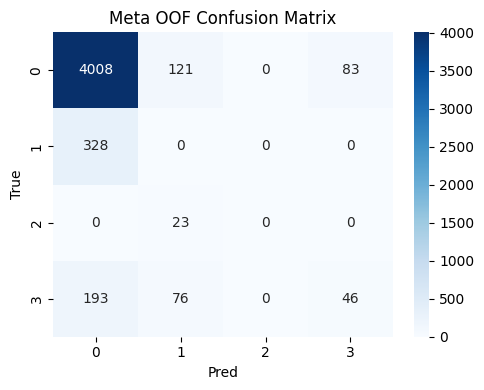

In [14]:
print(classification_report(y, oof_meta.argmax(axis=1), digits=4))

cm = confusion_matrix(y, oof_meta.argmax(axis=1), labels=[0,1,2,3])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel('Pred')
plt.ylabel('True')
plt.title('Meta OOF Confusion Matrix')
plt.tight_layout()
plt.show()


In [15]:
# 概率缩放搜索：优化宏F1（提升少数类召回）
def predict_with_scales(proba, scales):
    s = proba * np.array(scales).reshape(1, -1)
    return s.argmax(axis=1)

best_scales = [1.0, 1.0, 1.0, 1.0]
best_score = f1_score(y, oof_meta.argmax(axis=1), average='macro')

# 先粗搜
for s1 in np.arange(0.5, 5.1, 0.5):
    for s2 in np.arange(0.5, 8.1, 0.5):
        for s3 in np.arange(0.5, 5.1, 0.5):
            scales = [1.0, float(s1), float(s2), float(s3)]
            pred = predict_with_scales(oof_meta, scales)
            sc = f1_score(y, pred, average='macro')
            if sc > best_score:
                best_score = sc
                best_scales = scales

# 再细搜
base = best_scales
for s1 in np.arange(max(0.1, base[1]-0.6), base[1]+0.61, 0.1):
    for s2 in np.arange(max(0.1, base[2]-0.8), base[2]+0.81, 0.1):
        for s3 in np.arange(max(0.1, base[3]-0.6), base[3]+0.61, 0.1):
            scales = [1.0, float(s1), float(s2), float(s3)]
            pred = predict_with_scales(oof_meta, scales)
            sc = f1_score(y, pred, average='macro')
            if sc > best_score:
                best_score = sc
                best_scales = scales

print('Best scales:', best_scales)
print('Best OOF Macro F1 (scaled):', best_score)

# 用最优缩放得到最终测试预测
final_pred = predict_with_scales(meta_test_pred, best_scales).astype(int)


Best scales: [1.0, 0.1, 0.1, 3.0000000000000004]
Best OOF Macro F1 (scaled): 0.34905362714811305


In [16]:
# 生成提交
# 若上一个cell定义了final_pred（阈值优化后），直接使用；否则退回argmax
if 'final_pred' not in globals():
    final_pred = meta_test_pred.argmax(axis=1).astype(int)

sub = pd.DataFrame({
    'measurement_id': test_df['measurement_id'].astype(int),
    'Bearing_health_state': final_pred
})

sub_path = OUTPUT_DIR / 'submission.csv'
sub.to_csv(sub_path, index=False)
print('Saved:', sub_path.resolve())
print('rows:', len(sub), 'unique ids:', sub['measurement_id'].nunique())
print(sub.head())
print('label dist:')
print(sub['Bearing_health_state'].value_counts().sort_index())


Saved: /Users/songling/Desktop/public/working/submission.csv
rows: 1568 unique ids: 1568
   measurement_id  Bearing_health_state
0            4878                     0
1            4879                     0
2            4880                     0
3            4881                     0
4            4882                     0
label dist:
Bearing_health_state
0    1568
Name: count, dtype: int64
